# TAO Velocity Outlier Check

Checks four TAO velocity profile datasets for outliers that are likely
bad measurements (vs dynamical extremes):

- `TAO_WO_2012_CUR_v2.nc`  — point current meter, 2012
- `TAO_WO_2012_ADCP_v2.nc` — ADCP, 2012
- `TAO_WO_2013_CUR.nc`     — point current meter, 2013
- `TAO_WO_2013_ADCP.nc`    — ADCP, 2013

Outlier criterion: robust z-score (MAD-based) per depth level > threshold.
Physical plausibility cap: |U| > 2.5 m/s or |V| > 2.0 m/s flagged regardless.

Produces a single 6-panel summary figure.

In [2]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.size'] = 11

# ── paths ────────────────────────────────────────────────────────────────────
TAO_DIR = '/data/SO3/edavenport/tpose6/tao_profiles/'

FILE_SPECS = [
    dict(fname='TAO_WO_2012_CUR_v2.nc',  label='CUR 2012',  kind='CUR',  year=2012),
    dict(fname='TAO_WO_2012_ADCP_v2.nc', label='ADCP 2012', kind='ADCP', year=2012),
    dict(fname='TAO_WO_2013_CUR.nc',     label='CUR 2013',  kind='CUR',  year=2013),
    dict(fname='TAO_WO_2013_ADCP.nc',    label='ADCP 2013', kind='ADCP', year=2013),
]

def resolve_path(spec):
    p = TAO_DIR + spec['fname']
    if os.path.exists(p):
        return p
    raise FileNotFoundError(f"Cannot find {p}")

FILL        = -9999.
PHYS_CAP_U  = 2.5   # m/s — beyond EUC maximum; flag as physically implausible
PHYS_CAP_V  = 2.0
ZSCORE_CRIT = 5.0   # robust z-score threshold; 3 shown as secondary in histograms

In [3]:
# ── helpers ──────────────────────────────────────────────────────────────────

def mad_zscore_1d(x):
    """Robust z-score using MAD; NaNs propagated."""
    valid = x[np.isfinite(x)]
    if len(valid) < 5:
        return np.full_like(x, np.nan)
    med = np.median(valid)
    mad = np.median(np.abs(valid - med))
    if mad == 0:
        return np.zeros_like(x)
    return (x - med) / (1.4826 * mad)   # 1.4826 scales MAD to σ for Gaussian


def load_dataset(spec):
    """
    Load a profile file, mask fill values, and compute per-depth
    robust z-scores and outlier flags.

    All four files share layout (iPROF, iDEPTH).

    Returns dict with keys:
        U, V          : 2-D arrays, shape (n_prof, n_depth)
        depth         : 1-D array (m, positive down)
        lon, yyyymmdd : 1-D arrays (n_prof,)
        zU, zV        : robust z-scores, same shape as U/V
        bad_phys      : boolean mask, physically implausible
        bad_zscore    : boolean mask, |z| > ZSCORE_CRIT
        bad           : bad_phys | bad_zscore
        kind, label, year
    """
    path = resolve_path(spec)
    ds   = xr.open_dataset(path)

    U    = ds['prof_U'].values.astype(float)        # (iPROF, iDEPTH)
    V    = ds['prof_V'].values.astype(float)
    dep  = ds['prof_depth'].values.astype(float)
    lon  = ds['prof_lon'].values.astype(float)
    date = ds['prof_YYYYMMDD'].values.astype(float)
    ds.close()

    # mask fill
    U[U < -999.] = np.nan
    V[V < -999.] = np.nan

    n_prof, n_depth = U.shape

    # ── per-depth robust z-scores ─────────────────────────────────────────
    zU = np.full_like(U, np.nan)
    zV = np.full_like(V, np.nan)
    for id in range(n_depth):
        zU[:, id] = mad_zscore_1d(U[:, id])
        zV[:, id] = mad_zscore_1d(V[:, id])

    # ── outlier masks ─────────────────────────────────────────────────────
    bad_phys   = (np.abs(U) > PHYS_CAP_U) | (np.abs(V) > PHYS_CAP_V)
    bad_zscore = (np.abs(zU) > ZSCORE_CRIT) | (np.abs(zV) > ZSCORE_CRIT)
    bad        = bad_phys | bad_zscore

    return dict(
        U=U, V=V, depth=dep, lon=lon, yyyymmdd=date,
        zU=zU, zV=zV,
        bad_phys=bad_phys, bad_zscore=bad_zscore, bad=bad,
        kind=spec['kind'], label=spec['label'], year=spec['year'],
        n_prof=n_prof, n_depth=n_depth,
    )


datasets = {}
for spec in FILE_SPECS:
    d = load_dataset(spec)
    datasets[spec['label']] = d
    n_bad  = int(np.nansum(d['bad']))
    n_val  = int(np.sum(np.isfinite(d['U'])))
    print(f"{spec['label']:12s}: {n_val:7d} valid obs,  {n_bad:5d} flagged  "
          f"({100*n_bad/max(n_val,1):.2f}%)  "
          f"[phys: {int(np.nansum(d['bad_phys']))}  zscr: {int(np.nansum(d['bad_zscore']))}]")

CUR 2012    :   20754 valid obs,      3 flagged  (0.01%)  [phys: 0  zscr: 3]
ADCP 2012   : 1322496 valid obs,     74 flagged  (0.01%)  [phys: 0  zscr: 74]
CUR 2013    :   16692 valid obs,      1 flagged  (0.01%)  [phys: 0  zscr: 1]
ADCP 2013   : 1365809 valid obs,     43 flagged  (0.00%)  [phys: 0  zscr: 43]


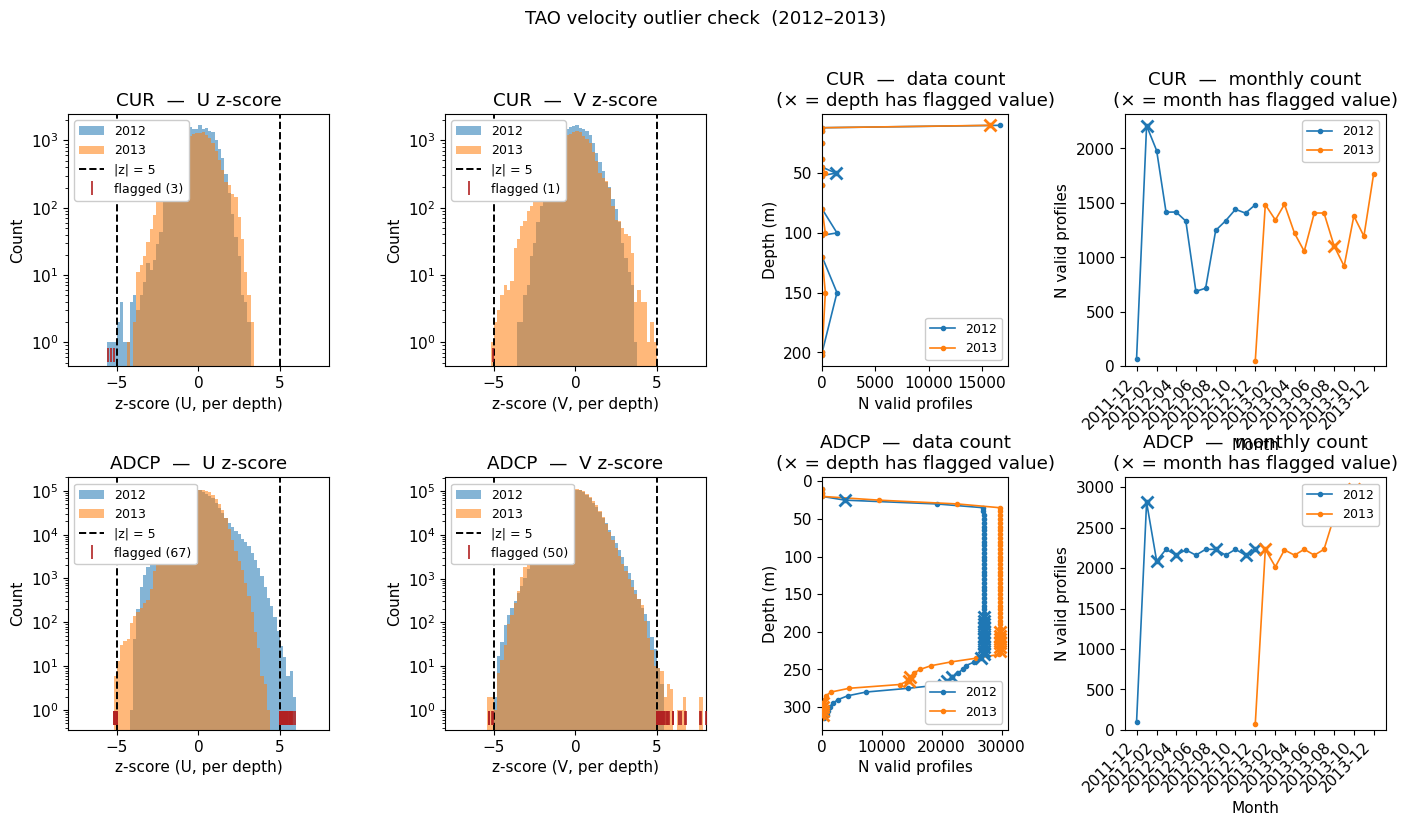

Figure saved.


In [4]:
# ── single summary figure ─────────────────────────────────────────────────────
#
# Layout (2 rows × 4 cols)
#   [0,0]  zU histogram — CUR      [0,1]  zV histogram — CUR
#   [1,0]  zU histogram — ADCP     [1,1]  zV histogram — ADCP
#   [0,2]  N_valid vs depth — CUR   (× at flagged depths)
#   [1,2]  N_valid vs depth — ADCP  (× at flagged depths)
#   [0,3]  N_valid vs month — CUR   (× at months with flags)
#   [1,3]  N_valid vs month — ADCP  (× at months with flags)
#
# Histograms show per-depth robust z-scores (MAD-based), log y-axis.
# ─────────────────────────────────────────────────────────────────────────────

import datetime
import matplotlib.dates as mdates

COLORS = {'CUR 2012': '#1f77b4', 'CUR 2013': '#ff7f0e',
          'ADCP 2012': '#1f77b4', 'ADCP 2013': '#ff7f0e'}
ALPHA  = 0.55
N_BINS = 80
RUG_Y  = 0.65
Z_LIM  = 8

fig, axes = plt.subplots(2, 4, figsize=(17, 8),
                         gridspec_kw={'width_ratios': [1.4, 1.4, 1.0, 1.4]})
fig.subplots_adjust(wspace=0.48, hspace=0.44)

for row_idx, kind in enumerate(['CUR', 'ADCP']):
    cur_ds = {lbl: d for lbl, d in datasets.items() if d['kind'] == kind}

    ax_u   = axes[row_idx, 0]
    ax_v   = axes[row_idx, 1]
    ax_dep = axes[row_idx, 2]
    ax_t   = axes[row_idx, 3]

    # ── z-score histograms ────────────────────────────────────────────────
    bins = np.linspace(-Z_LIM, Z_LIM, N_BINS + 1)

    for ax, zcomp, comp_label in [(ax_u, 'zU', 'U'), (ax_v, 'zV', 'V')]:

        for lbl, d in cur_ds.items():
            zvals = d[zcomp].ravel()
            zvals = zvals[np.isfinite(zvals)]
            ax.hist(zvals, bins=bins, color=COLORS[lbl], alpha=ALPHA,
                    label=lbl.split()[-1], log=True, density=False)

        ax.axvline( ZSCORE_CRIT, color='k', lw=1.4, ls='--')
        ax.axvline(-ZSCORE_CRIT, color='k', lw=1.4, ls='--', label=f'|z| = {ZSCORE_CRIT:.0f}')

        flagged_z = []
        n_flagged = 0
        for lbl, d in cur_ds.items():
            zvals = d[zcomp].ravel()
            flag  = (np.abs(d[zcomp]) > ZSCORE_CRIT).ravel()
            fz    = zvals[flag & np.isfinite(zvals)]
            flagged_z.append(fz)
            n_flagged += len(fz)
        flagged_z = np.concatenate(flagged_z)
        if len(flagged_z):
            ax.plot(flagged_z, np.full_like(flagged_z, RUG_Y),
                    '|', color='firebrick', ms=10, mew=1.2,
                    label=f'flagged ({n_flagged})', zorder=5)

        ax.set_xlim(-Z_LIM, Z_LIM)
        ax.set_xlabel(f'z-score ({comp_label}, per depth)')
        ax.set_ylabel('Count')
        ax.set_title(f'{kind}  —  {comp_label} z-score')
        ax.legend(fontsize=9, title_fontsize=9, loc='upper left', framealpha=1)

    # ── N_valid vs depth; × at flagged depth levels ───────────────────────
    for lbl, d in cur_ds.items():
        n_valid  = np.array([int(np.sum(np.isfinite(d['U'][:, id])))
                              for id in range(d['n_depth'])], dtype=float)
        has_flag = np.array([np.any(d['bad'][:, id] & np.isfinite(d['U'][:, id]))
                              for id in range(d['n_depth'])])
        c = COLORS[lbl]
        ax_dep.plot(n_valid, d['depth'], '-o', ms=3, color=c,
                    label=lbl.split()[-1], lw=1.2)
        if has_flag.any():
            ax_dep.plot(n_valid[has_flag], d['depth'][has_flag],
                        'x', ms=8, mew=2, color=c, zorder=5)

    ax_dep.set_xlabel('N valid profiles')
    ax_dep.set_ylabel('Depth (m)')
    ax_dep.set_title(f'{kind}  —  data count\n(× = depth has flagged value)')
    ax_dep.invert_yaxis()
    ax_dep.set_xlim(left=0)
    ax_dep.legend(fontsize=9, title_fontsize=9, loc='lower right', framealpha=1)

    # ── N_valid vs month; time on x-axis; × at months with flags ─────────
    for lbl, d in cur_ds.items():
        dates     = d['yyyymmdd']
        bad_prof  = d['bad'].any(axis=1)
        valid_any = np.isfinite(d['U']).any(axis=1)

        ym_all = np.array([int(v) // 100 for v in dates[valid_any]], dtype=int)
        ym_bad = np.array([int(dates[i]) // 100
                           for i in np.where(bad_prof & valid_any)[0]], dtype=int)

        unique_ym   = np.unique(ym_all)
        n_per_month = np.array([np.sum(ym_all == ym) for ym in unique_ym], dtype=float)
        month_dts   = [datetime.date(ym // 100, ym % 100, 1) for ym in unique_ym]

        c = COLORS[lbl]
        ax_t.plot(month_dts, n_per_month, '-o', ms=3, color=c,
                  label=lbl.split()[-1], lw=1.2)

        for fym in np.unique(ym_bad):
            idx = np.where(unique_ym == fym)[0]
            if len(idx):
                ax_t.plot(datetime.date(fym // 100, fym % 100, 1),
                          n_per_month[idx[0]],
                          'x', ms=8, mew=2, color=c, zorder=5)

    ax_t.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax_t.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax_t.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax_t.set_ylim(bottom=0)
    ax_t.set_xlabel('Month')
    ax_t.set_ylabel('N valid profiles')
    ax_t.set_title(f'{kind}  —  monthly count\n(× = month has flagged value)')
    ax_t.legend(fontsize=9, title_fontsize=9, loc='upper right', framealpha=1)

fig.suptitle('TAO velocity outlier check  (2012–2013)', fontsize=13, y=1.01)
plt.savefig('TAO_velocity_outlier_check.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

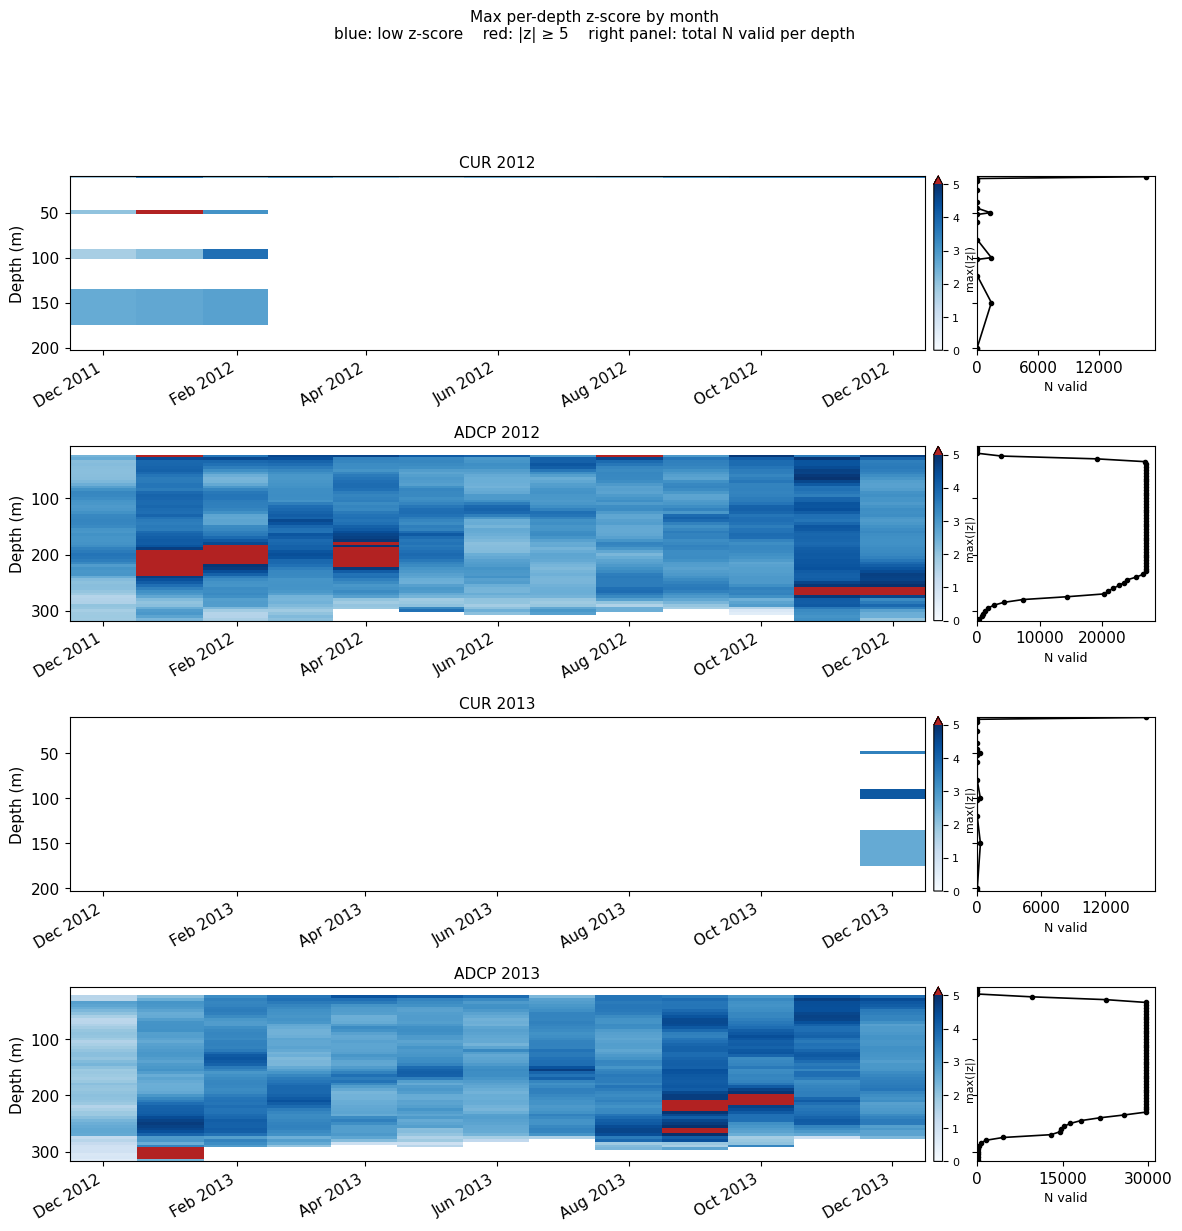

Heatmap figure saved.


In [5]:
# ── Figure 2: depth × time heatmap of max(|z|) with N_valid side panel ───────
#
# Each row = one dataset.  Main panel: max(|zU|, |zV|) per (depth, month),
# colormap 0→5 in blue, >5 in red.  Side panel (shared depth y-axis): total
# N_valid per depth.  The red cells should line up with the sparse depths,
# showing the flags are sampling artifacts rather than instrument errors.
# ─────────────────────────────────────────────────────────────────────────────

import datetime
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

def build_max_z_grid(d):
    """(n_depth × n_months) grid of max(|zU|, |zV|), plus month date list."""
    months_arr = np.array([int(v) // 100 for v in d['yyyymmdd']], dtype=int)
    unique_ym  = np.unique(months_arr)
    grid = np.full((d['n_depth'], len(unique_ym)), np.nan)
    for mi, m in enumerate(unique_ym):
        mask = months_arr == m
        if mask.any():
            max_z_m = np.maximum(np.abs(d['zU'][mask, :]),
                                 np.abs(d['zV'][mask, :]))
            grid[:, mi] = np.nanmax(max_z_m, axis=0)
    month_dts = [datetime.date(ym // 100, ym % 100, 1) for ym in unique_ym]
    return grid, month_dts

def make_edges(vals):
    """Cell edges for an array of centre values (handles irregular spacing)."""
    e = np.empty(len(vals) + 1)
    e[1:-1] = 0.5 * (vals[:-1] + vals[1:])
    e[0]    = vals[0]  - 0.5 * (vals[1]  - vals[0])
    e[-1]   = vals[-1] + 0.5 * (vals[-1] - vals[-2])
    return e

# colormap: light blue for low z, saturates at 5, firebrick for >5
cmap_hm = plt.cm.Blues.copy()
cmap_hm.set_over('firebrick')
norm_hm = mcolors.Normalize(vmin=0, vmax=ZSCORE_CRIT)

n_ds  = len(FILE_SPECS)
fig2  = plt.figure(figsize=(14, 3.2 * n_ds))
gs    = GridSpec(n_ds, 2, figure=fig2,
                 width_ratios=[5, 1], wspace=0.04, hspace=0.55)

for row_idx, spec in enumerate(FILE_SPECS):
    d               = datasets[spec['label']]
    grid, month_dts = build_max_z_grid(d)

    dep      = d['depth']
    x_edges  = make_edges(mdates.date2num(month_dts))
    y_edges  = make_edges(dep)
    X, Y     = np.meshgrid(x_edges, y_edges)

    ax_hm = fig2.add_subplot(gs[row_idx, 0])
    ax_n  = fig2.add_subplot(gs[row_idx, 1], sharey=ax_hm)

    # ── heatmap ───────────────────────────────────────────────────────────
    pcm = ax_hm.pcolormesh(X, Y, grid, cmap=cmap_hm, norm=norm_hm)
    ax_hm.xaxis_date()
    ax_hm.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax_hm.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax_hm.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax_hm.invert_yaxis()
    ax_hm.set_ylabel('Depth (m)')
    ax_hm.set_title(spec['label'], fontsize=11)

    cb = fig2.colorbar(pcm, ax=ax_hm, orientation='vertical',
                       pad=0.01, fraction=0.025, extend='max')
    cb.set_label('max(|z|)', fontsize=8)
    cb.ax.tick_params(labelsize=8)

    # ── N_valid side panel ────────────────────────────────────────────────
    n_valid = np.array([int(np.sum(np.isfinite(d['U'][:, id])))
                         for id in range(d['n_depth'])], dtype=float)
    ax_n.plot(n_valid, dep, '-o', ms=3, color='k', lw=1.2)
    ax_n.set_xlabel('N valid', fontsize=9)
    ax_n.tick_params(axis='y', labelleft=False)
    ax_n.set_xlim(left=0)
    ax_n.xaxis.set_major_locator(plt.MaxNLocator(3))

fig2.suptitle(
    'Max per-depth z-score by month\n'
    'blue: low z-score    red: |z| ≥ 5    right panel: total N valid per depth',
    fontsize=11, y=1.01)
plt.savefig('TAO_velocity_outlier_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap figure saved.')

Per-location outlier summary:
Kind Lon        N valid   |z|>5   phys   %flag
----------------------------------------------------
ADCP 165°E       187901      21      0   0.011%
ADCP 170°W       800224     674      0   0.084%
ADCP 140°W       863614      35      0   0.004%
ADCP 110°W       836566       0      0   0.000%
CUR  147°E        15435       0      0   0.000%
CUR  156°E        15414       0      0   0.000%
CUR  170°W         6597       9      0   0.136%


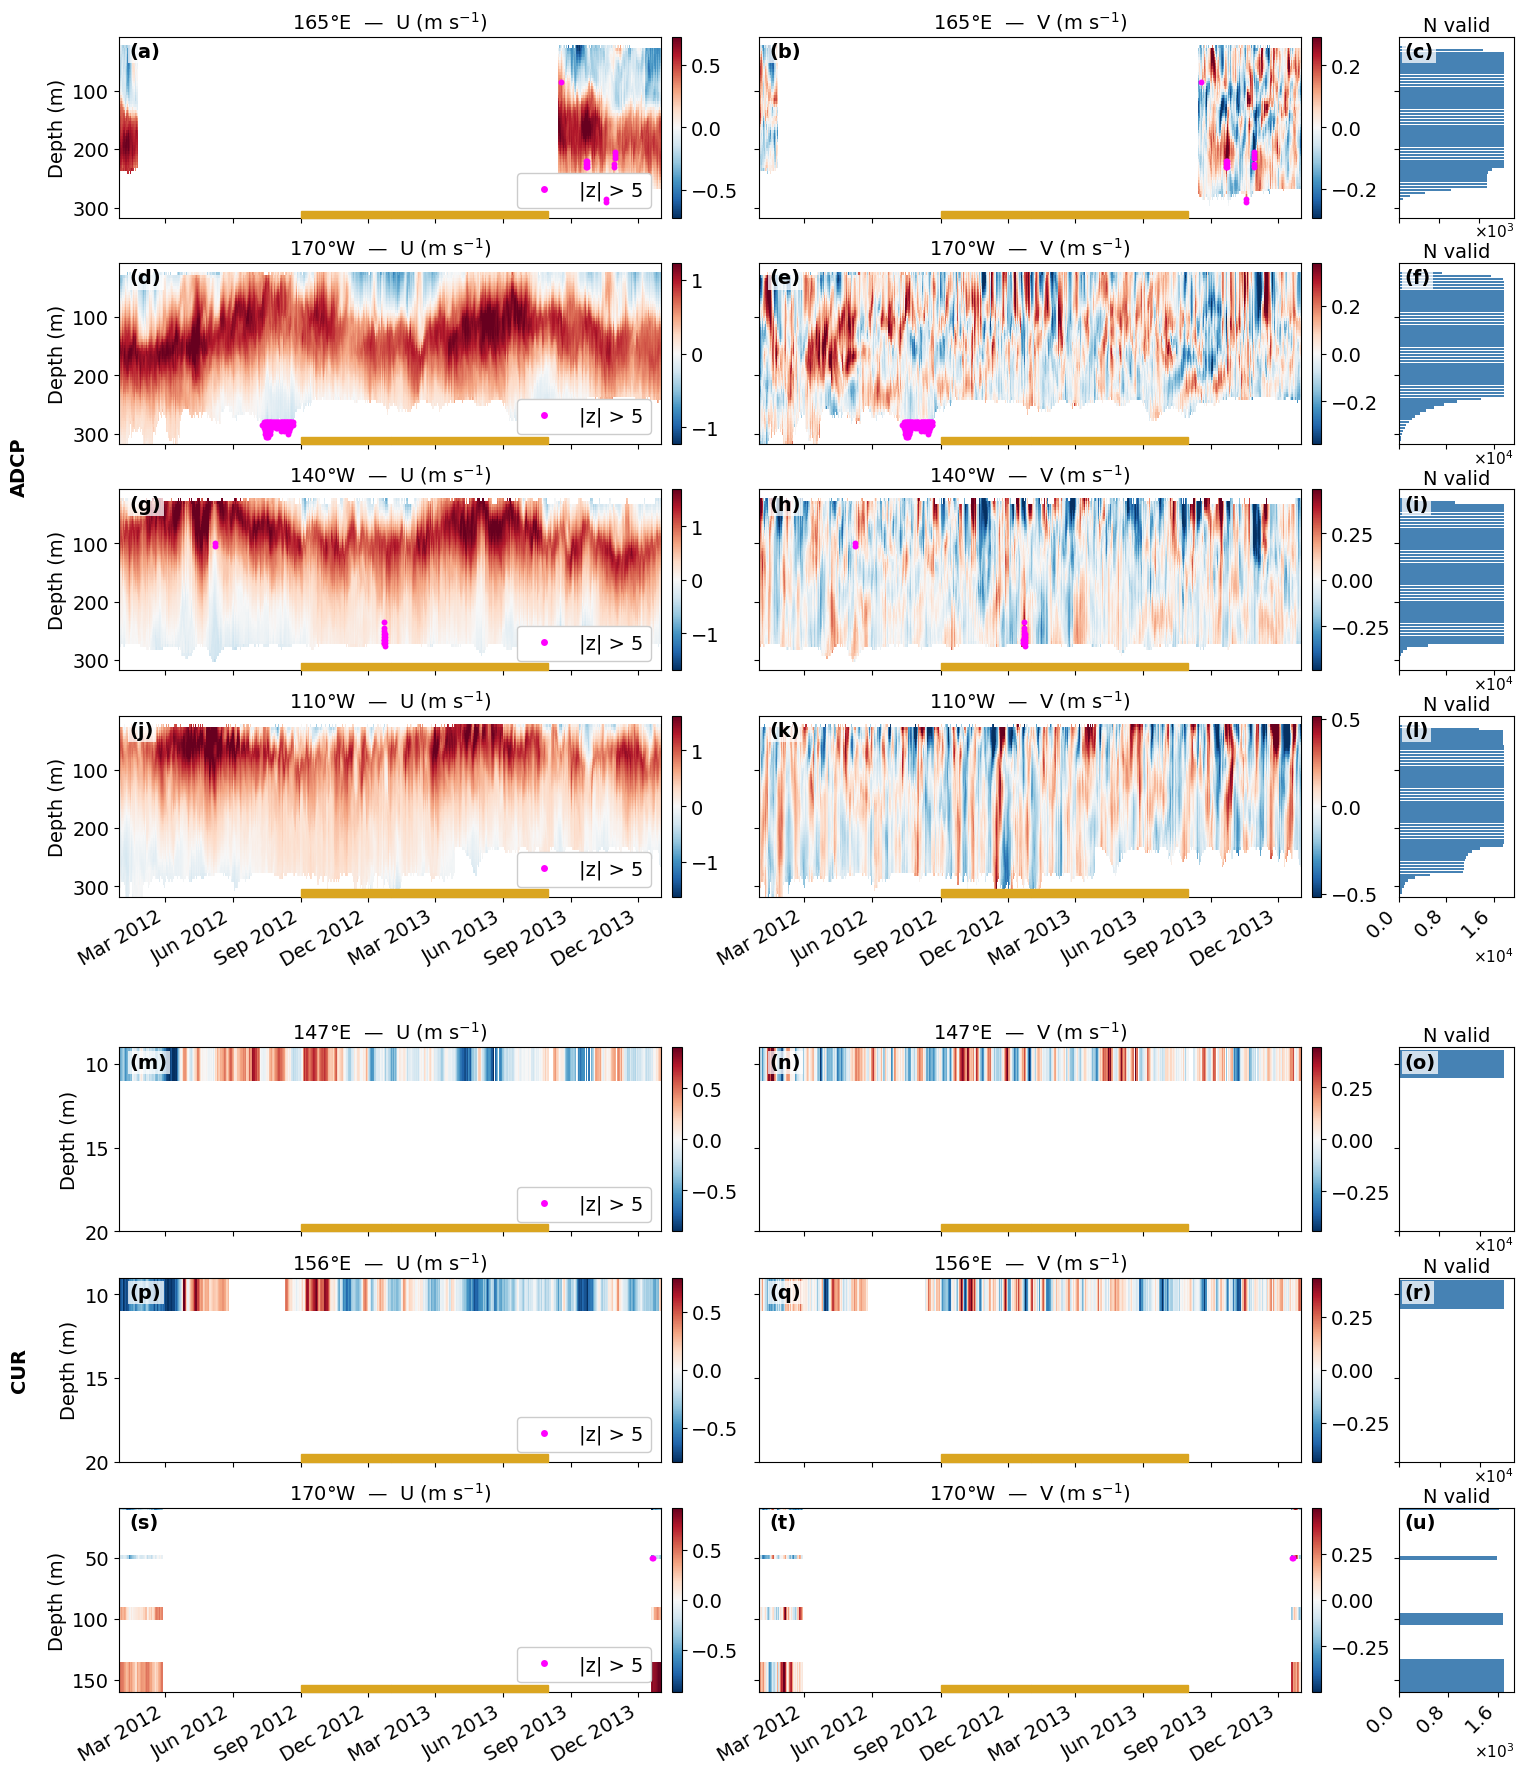

Time-series figure saved.


In [7]:
# ── Figure 3: depth × time velocity by location, years concatenated ───────────
#
# Rows: 4 ADCP locations (165°E, 170°W, 140°W, 110°W)
#       3 CUR  locations (147°E, 156°E, 170°W)
# Columns: U (m/s), V (m/s), N valid per depth
# Z-scores and outlier flags computed per location.
# Magenta dots: max(|zU|,|zV|) > 5 at that (depth, date).
# Gold band: assimilation experiment window.
# ─────────────────────────────────────────────────────────────────────────────

import datetime, warnings, string
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

FONT_SIZE = 14

# ── per-location data loading ─────────────────────────────────────────────────

def lon_label(lon):
    return f'{int(360-lon)}°W' if lon > 180 else f'{int(lon)}°E'

def load_location_datasets(fnames):
    """Load files, concatenate all years, split by lon; z-scores per location."""
    all_U, all_V, all_date, all_lon = [], [], [], []
    dep = None
    for fname in fnames:
        ds = xr.open_dataset(TAO_DIR + fname)
        U = ds['prof_U'].values.astype(float)
        V = ds['prof_V'].values.astype(float)
        if dep is None:
            dep = ds['prof_depth'].values.astype(float)
        all_lon.append(ds['prof_lon'].values.astype(float))
        all_date.append(ds['prof_YYYYMMDD'].values.astype(float))
        all_U.append(U); all_V.append(V)
        ds.close()

    U_cat    = np.vstack(all_U);  U_cat[U_cat < -999.] = np.nan
    V_cat    = np.vstack(all_V);  V_cat[V_cat < -999.] = np.nan
    date_cat = np.concatenate(all_date)
    lon_cat  = np.concatenate(all_lon)

    results = []
    for lon in np.unique(np.round(lon_cat, 1)):
        mask  = np.round(lon_cat, 1) == lon
        U     = U_cat[mask].copy()
        V     = V_cat[mask].copy()
        dates = date_cat[mask]

        order = np.argsort(dates)
        U = U[order]; V = V[order]; dates = dates[order]

        n_prof, n_depth = U.shape

        zU = np.full_like(U, np.nan)
        zV = np.full_like(V, np.nan)
        for k in range(n_depth):
            zU[:, k] = mad_zscore_1d(U[:, k])
            zV[:, k] = mad_zscore_1d(V[:, k])

        bad_phys   = (np.abs(U) > PHYS_CAP_U) | (np.abs(V) > PHYS_CAP_V)
        bad_zscore = (np.abs(zU) > ZSCORE_CRIT) | (np.abs(zV) > ZSCORE_CRIT)
        bad        = bad_phys | bad_zscore

        n_valid_per_depth = np.array([np.sum(np.isfinite(U[:, k])) for k in range(n_depth)])
        valid_depths = dep[n_valid_per_depth > 5]
        max_data_depth = valid_depths.max() + 10 if len(valid_depths) else dep[0] + 10

        results.append(dict(
            U=U, V=V, depth=dep, yyyymmdd=dates,
            zU=zU, zV=zV,
            bad_phys=bad_phys, bad_zscore=bad_zscore, bad=bad,
            lon=lon, label=lon_label(lon),
            n_prof=n_prof, n_depth=n_depth,
            max_data_depth=max_data_depth,
        ))
    return results

ADCP_FILES = ['TAO_WO_2012_ADCP_v2.nc', 'TAO_WO_2013_ADCP.nc']
CUR_FILES  = ['TAO_WO_2012_CUR_v2.nc',  'TAO_WO_2013_CUR.nc']

adcp_loc = load_location_datasets(ADCP_FILES)
cur_loc  = load_location_datasets(CUR_FILES)

print('Per-location outlier summary:')
print(f"{'Kind':4s} {'Lon':8s}  {'N valid':>8s}  {'|z|>5':>6s}  {'phys':>5s}  {'%flag':>6s}")
print('-' * 52)
for kind, dlist in [('ADCP', adcp_loc), ('CUR', cur_loc)]:
    for d in dlist:
        n_val  = int(np.sum(np.isfinite(d['U'])))
        n_z    = int(np.nansum(d['bad_zscore']))
        n_phys = int(np.nansum(d['bad_phys']))
        print(f"{kind:4s} {d['label']:8s}  {n_val:8d}  {n_z:6d}  {n_phys:5d}  "
              f"{100*(n_z+n_phys)/max(n_val,1):6.3f}%")


# ── helper functions ──────────────────────────────────────────────────────────

def build_daily_grids(d):
    dates_int    = np.array([int(v) for v in d['yyyymmdd']], dtype=int)
    unique_dates = np.unique(dates_int)
    n_dep        = d['n_depth']

    u_grid    = np.full((n_dep, len(unique_dates)), np.nan)
    v_grid    = np.full((n_dep, len(unique_dates)), np.nan)
    flag_grid = np.zeros((n_dep, len(unique_dates)), dtype=bool)

    for di, date in enumerate(unique_dates):
        mask = dates_int == date
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            u_grid[:, di] = np.nanmedian(d['U'][mask, :], axis=0)
            v_grid[:, di] = np.nanmedian(d['V'][mask, :], axis=0)
        flag_grid[:, di] = d['bad'][mask, :].any(axis=0)

    date_dts = [datetime.date(v // 10000, (v % 10000) // 100, v % 100)
                for v in unique_dates]
    return u_grid, v_grid, flag_grid, date_dts


def add_stipple(ax, flag_grid, date_dts, depths, color='magenta', size=18):
    date_nums = mdates.date2num(date_dts)
    rows, cols = np.where(flag_grid)
    if len(rows):
        ax.scatter(date_nums[cols], depths[rows],
                   s=size, c=color, marker='o', zorder=6, linewidths=0)


def add_expt_band(ax, start, end):
    ax.axvspan(mdates.date2num(start), mdates.date2num(end),
               ymin=0, ymax=0.04, color='goldenrod', alpha=1.0, zorder=7,
               clip_on=False, transform=ax.get_xaxis_transform())


def plot_row(ax_u, ax_v, ax_n, d, panel_labels,
             ylim_bottom=None, show_xticklabels=True):
    dep = d['depth']
    u_grid, v_grid, flag_grid, date_dts = build_daily_grids(d)

    date_nums = mdates.date2num(date_dts)
    x_edges   = make_edges(date_nums)
    y_edges   = make_edges(dep)
    X, Y      = np.meshgrid(x_edges, y_edges)

    for ax, grid, comp in [(ax_u, u_grid, 'U'), (ax_v, v_grid, 'V')]:
        vabs   = np.nanpercentile(np.abs(grid), 99)
        norm_v = mcolors.TwoSlopeNorm(vmin=-vabs, vcenter=0, vmax=vabs)
        pcm    = ax.pcolormesh(X, Y, grid, cmap='RdBu_r', norm=norm_v)
        ax.xaxis_date()
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        if show_xticklabels:
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right',
                     fontsize=FONT_SIZE)
        else:
            plt.setp(ax.xaxis.get_majorticklabels(), visible=False)
        ax.invert_yaxis()
        ax.tick_params(axis='y', labelsize=FONT_SIZE)

        cb = fig.colorbar(pcm, ax=ax, orientation='vertical', pad=0.02, fraction=0.04)
        cb.ax.tick_params(labelsize=FONT_SIZE)

        add_stipple(ax, flag_grid, date_dts, dep)
        dates_int = np.array([int(v) for v in d['yyyymmdd']], dtype=int)
        if np.any((dates_int >= 20120901) & (dates_int < 20130101)):
            add_expt_band(ax, datetime.date(2012, 9, 1), datetime.date(2013, 1, 1))
        if np.any((dates_int >= 20130101) & (dates_int < 20130801)):
            add_expt_band(ax, datetime.date(2013, 1, 1), datetime.date(2013, 8, 1))

        lbl = next(panel_labels)
        ax.text(0.02, 0.97, f'({lbl})', transform=ax.transAxes,
                fontsize=FONT_SIZE, fontweight='bold', va='top', ha='left',
                bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.5),
                zorder=10)

    ax_u.set_ylabel('Depth (m)', fontsize=FONT_SIZE)
    plt.setp(ax_v.get_yticklabels(), visible=False)

    from matplotlib.lines import Line2D
    ax_u.legend(handles=[Line2D([0],[0], marker='o', color='w',
                                markerfacecolor='magenta', markersize=6,
                                label='|z| > 5')],
                fontsize=FONT_SIZE, loc='lower right', framealpha=1)

    # N valid histogram
    n_valid     = np.array([int(np.sum(np.isfinite(d['U'][:, k])))
                            for k in range(d['n_depth'])], dtype=float)
    y_edges_loc = make_edges(dep)
    bar_heights = np.diff(y_edges_loc)
    ax_n.barh(dep, n_valid, height=bar_heights * 0.85,
              color='steelblue', edgecolor='none', align='center')
    ax_n.invert_yaxis()
    ax_n.set_title('N valid', fontsize=FONT_SIZE, pad=4)
    plt.setp(ax_n.get_yticklabels(), visible=False)
    ax_n.set_xlim(0, n_valid.max() * 1.1)
    ax_n.xaxis.set_major_locator(mticker.MaxNLocator(3))
    sci_fmt = mticker.ScalarFormatter(useMathText=True)
    sci_fmt.set_scientific(True); sci_fmt.set_powerlimits((0, 0))
    ax_n.xaxis.set_major_formatter(sci_fmt)
    if show_xticklabels:
        ax_n.tick_params(axis='x', labelsize=FONT_SIZE)
        plt.setp(ax_n.xaxis.get_majorticklabels(), rotation=45, ha='right')
    else:
        plt.setp(ax_n.xaxis.get_majorticklabels(), visible=False)

    lbl = next(panel_labels)
    ax_n.text(0.05, 0.97, f'({lbl})', transform=ax_n.transAxes,
              fontsize=FONT_SIZE, fontweight='bold', va='top', ha='left',
              bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.5),
              zorder=10)

    top_lim    = min(y_edges_loc[0], dep[0] - 1)
    bottom_lim = ylim_bottom if ylim_bottom is not None else y_edges_loc[-1]
    ax_u.set_ylim(top=top_lim, bottom=bottom_lim)


# ── figure layout ─────────────────────────────────────────────────────────────
n_adcp = len(adcp_loc)
n_cur  = len(cur_loc)
ROW_H  = 3.0

fig = plt.figure(figsize=(18, ROW_H * (n_adcp + n_cur) + 0.5))

outer = GridSpec(2, 1, figure=fig,
                 height_ratios=[n_adcp, n_cur],
                 hspace=0.2)

gs_adcp = GridSpecFromSubplotSpec(n_adcp, 3, subplot_spec=outer[0],
                                  width_ratios=[5, 5, 1],
                                  wspace=0.15, hspace=0.25)
gs_cur  = GridSpecFromSubplotSpec(n_cur,  3, subplot_spec=outer[1],
                                  width_ratios=[5, 5, 1],
                                  wspace=0.15, hspace=0.25)

panel_labels = iter(string.ascii_lowercase)

adcp_axes = []
cur_axes  = []
adcp_xref = None
cur_xref  = None

# ADCP rows — share x across all rows; show x tick labels only on bottom row
for row_idx, d in enumerate(adcp_loc):
    is_bottom = (row_idx == n_adcp - 1)
    if adcp_xref is None:
        ax_u = fig.add_subplot(gs_adcp[row_idx, 0])
        adcp_xref = ax_u
    else:
        ax_u = fig.add_subplot(gs_adcp[row_idx, 0], sharex=adcp_xref)
    ax_v = fig.add_subplot(gs_adcp[row_idx, 1], sharey=ax_u, sharex=adcp_xref)
    ax_n = fig.add_subplot(gs_adcp[row_idx, 2], sharey=ax_u)
    ax_u.set_title(f"{d['label']}  —  U (m s$^{{-1}}$)", fontsize=FONT_SIZE)
    ax_v.set_title(f"{d['label']}  —  V (m s$^{{-1}}$)", fontsize=FONT_SIZE)
    plot_row(ax_u, ax_v, ax_n, d, panel_labels, show_xticklabels=is_bottom)
    adcp_axes.append((ax_u, ax_v, ax_n))

# CUR rows — share x across all rows; show x tick labels only on bottom row
for row_idx, d in enumerate(cur_loc):
    is_bottom = (row_idx == n_cur - 1)
    if cur_xref is None:
        ax_u = fig.add_subplot(gs_cur[row_idx, 0])
        cur_xref = ax_u
    else:
        ax_u = fig.add_subplot(gs_cur[row_idx, 0], sharex=cur_xref)
    ax_v = fig.add_subplot(gs_cur[row_idx, 1], sharey=ax_u, sharex=cur_xref)
    ax_n = fig.add_subplot(gs_cur[row_idx, 2], sharey=ax_u)
    ax_u.set_title(f"{d['label']}  —  U (m s$^{{-1}}$)", fontsize=FONT_SIZE)
    ax_v.set_title(f"{d['label']}  —  V (m s$^{{-1}}$)", fontsize=FONT_SIZE)
    plot_row(ax_u, ax_v, ax_n, d, panel_labels,
             ylim_bottom=d['max_data_depth'], show_xticklabels=is_bottom)
    cur_axes.append((ax_u, ax_v, ax_n))

# Section labels: draw first to get actual positions, then place just left of axes
fig.canvas.draw()
for axes_list, label in [(adcp_axes, 'ADCP'), (cur_axes, 'CUR')]:
    x0    = axes_list[0][0].get_position().x0
    y_top = axes_list[0][0].get_position().y1
    y_bot = axes_list[-1][0].get_position().y0
    fig.text(x0 - 0.05, (y_top + y_bot) / 2, label,
             ha='right', va='center', fontsize=FONT_SIZE,
             fontweight='bold', rotation=90)

plt.savefig('TAO_velocity_outlier_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Time-series figure saved.')

In [6]:
# ── print summary table ───────────────────────────────────────────────────────
print(f"{'Dataset':12s}  {'N valid':>8s}  {'Phys cap':>9s}  {'|z|>5':>6s}  "
      f"{'U max':>7s}  {'V max':>7s}")
print('-' * 62)
for lbl, d in datasets.items():
    n_val   = int(np.sum(np.isfinite(d['U'])))
    n_phys  = int(np.nansum(d['bad_phys']))
    n_z5    = int(np.nansum(d['bad_zscore']))
    u_max   = np.nanmax(np.abs(d['U']))
    v_max   = np.nanmax(np.abs(d['V']))
    print(f"{lbl:12s}  {n_val:8d}  {n_phys:9d}  {n_z5:6d}  "
          f"{u_max:7.3f}  {v_max:7.3f}")

Dataset        N valid   Phys cap   |z|>5    U max    V max
--------------------------------------------------------------
CUR 2012         20754          0       3    1.122    0.744
ADCP 2012      1322496          0      74    2.412    0.985
CUR 2013         16692          0       1    1.062    0.668
ADCP 2013      1365809          0      43    2.059    1.011
